<a href="https://colab.research.google.com/github/vmaddi2-cloud/FDS-Titanic-Dataset/blob/main/FDS_AUTOMOBILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Automobile_data.csv")
df.replace("?", np.nan, inplace=True)

print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

First 5 Records
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3               NaN  alfa-romero       gas        std          two   
1          3               NaN  alfa-romero       gas        std          two   
2          1               NaN  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compr

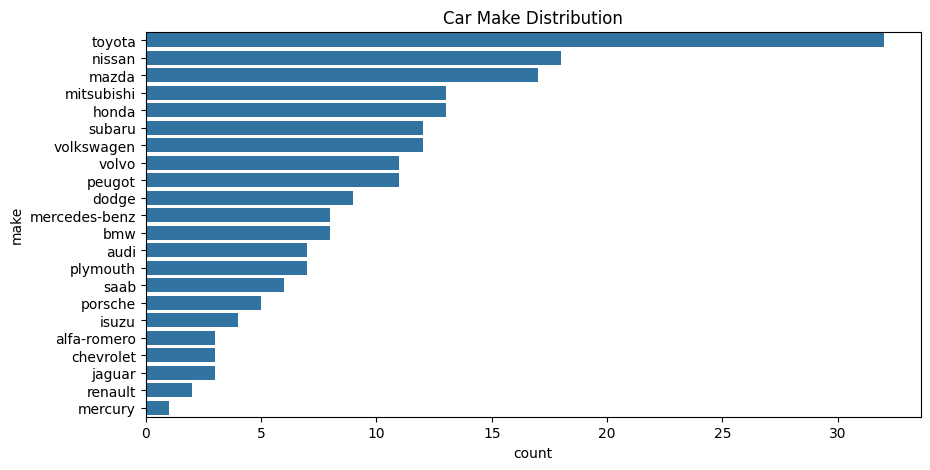

In [3]:
# Car Make Distribution
plt.figure(figsize=(10,5))
sns.countplot(y='make', data=df,
              order=df['make'].value_counts().index)
plt.title("Car Make Distribution")
plt.show()

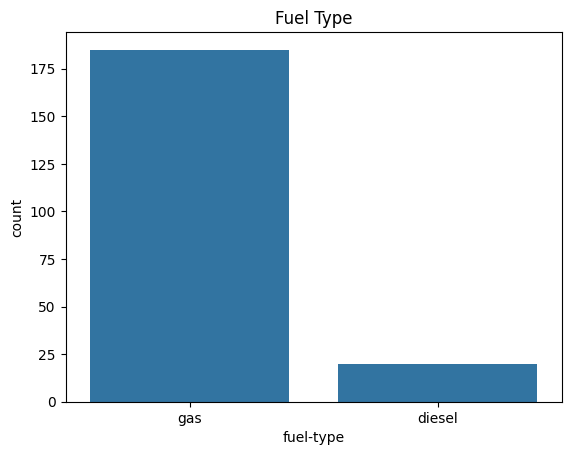

In [4]:
# Fuel Type Distribution
sns.countplot(x='fuel-type', data=df)
plt.title("Fuel Type")
plt.show()

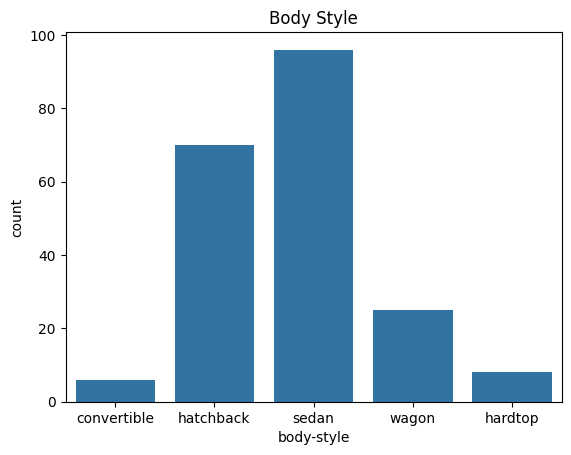

In [5]:
# Body Style Distribution
sns.countplot(x='body-style', data=df)
plt.title("Body Style")
plt.show()

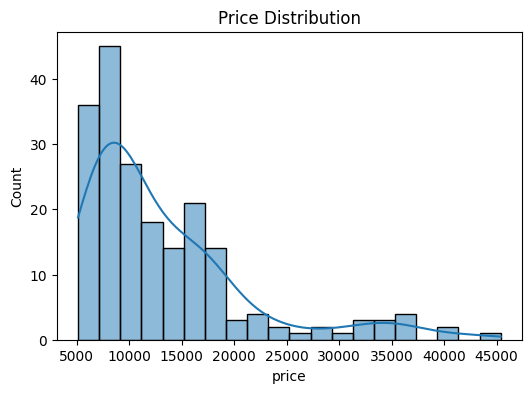

In [6]:
# Price Distribution
df['price'] = pd.to_numeric(df['price'], errors='coerce')

plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

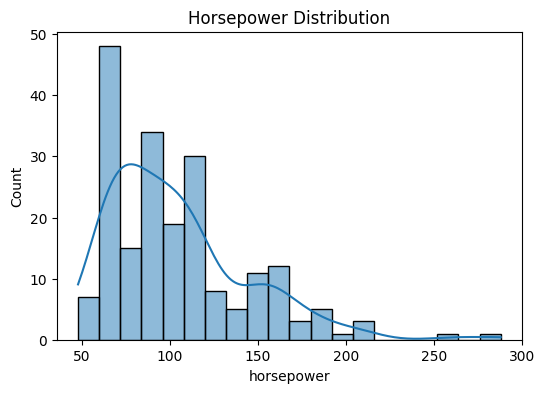

In [7]:
# Horsepower Distribution
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

plt.figure(figsize=(6,4))
sns.histplot(df['horsepower'], bins=20, kde=True)
plt.title("Horsepower Distribution")
plt.show()

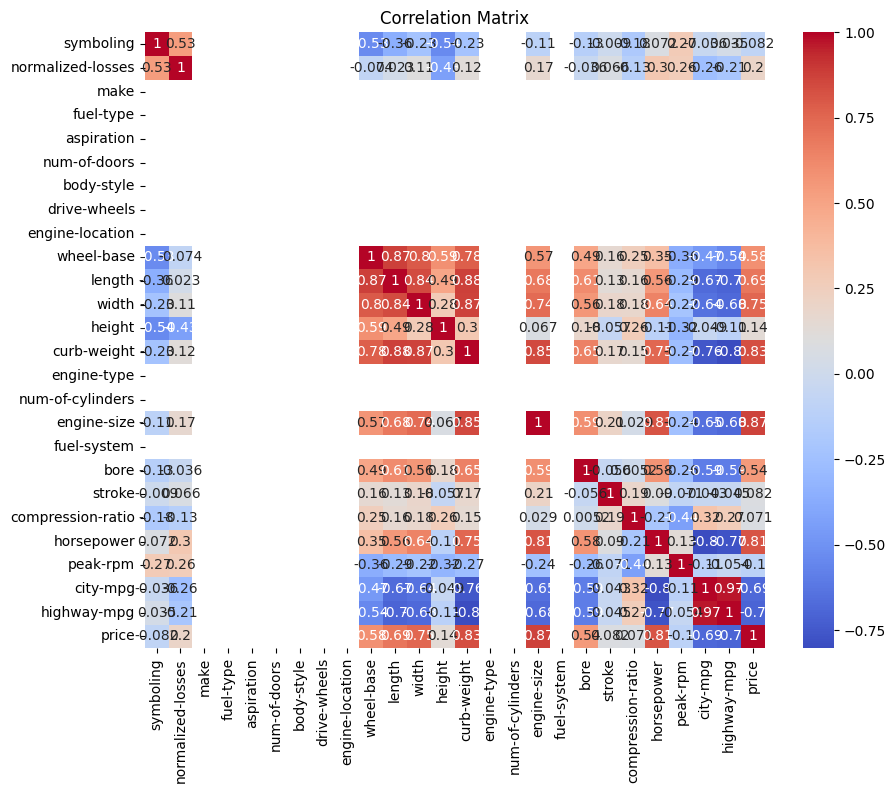

In [8]:
# Correlation Heatmap
numeric_df = df.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


In [9]:
print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64','float64']).columns
print(numeric)

print("\nNominal Attributes")
nominal = ['make','fuel-type']
print(nominal)

print("\nBinary Attributes")
binary = ['fuel-type']
print(binary)



Numeric Attributes
Index(['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight',
       'engine-size', 'compression-ratio', 'horsepower', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

Nominal Attributes
['make', 'fuel-type']

Binary Attributes
['fuel-type']


In [10]:
make = df['make']
fuel = df['fuel-type']

count = 0
total = 0

for m, f in zip(make, fuel):

    if pd.isna(m) or pd.isna(f):
        continue

    total += 1

    if m != f:
        count += 1

dissimilarity = count / total

print("\nNominal Attribute Dissimilarity")
print("Make vs Fuel Type =", dissimilarity)



Nominal Attribute Dissimilarity
Make vs Fuel Type = 1.0


In [11]:
df['engine-size'] = pd.to_numeric(df['engine-size'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

temp = df[['engine-size','horsepower']].dropna()

engine1 = temp.iloc[0]['engine-size']
horse1 = temp.iloc[0]['horsepower']

engine2 = temp.iloc[1]['engine-size']
horse2 = temp.iloc[1]['horsepower']


In [12]:
distance = np.sqrt((engine1-engine2)**2 +
                   (horse1-horse2)**2)

print("\nEuclidean Distance")
print(distance)



Euclidean Distance
0.0


In [13]:
manhattan = abs(engine1-engine2) + abs(horse1-horse2)

print("\nManhattan Distance")
print(manhattan)


Manhattan Distance
0.0


In [14]:
minkowski = ((abs(engine1-engine2)**3) +
             (abs(horse1-horse2)**3))**(1/3)

print("\nMinkowski Distance")
print(minkowski)


Minkowski Distance
0.0


In [15]:
A = np.array([engine1, horse1])
B = np.array([engine2, horse2])

cosine_similarity = np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))
cosine_dissimilarity = 1 - cosine_similarity

print("\nCosine Dissimilarity")
print(cosine_dissimilarity)


Cosine Dissimilarity
-2.220446049250313e-16
